# Group 2 — Instacart Association Rule Mining

Solution notebook (Python). This notebook implements the required steps for the Group 2 practical assignment (Instacart dataset). It uses `pandas`, `mlxtend` and `matplotlib`/`seaborn`. If you don't have the Instacart CSVs locally, a small synthetic example will run to demonstrate the pipeline.

Place the Instacart CSV files (`orders.csv`, `order_products__prior.csv`, `products.csv`) in a `data/` folder next to this notebook to run on the real data.

**Outputs:** frequent itemsets (Apriori/FP-Growth), association rules, visualizations, and runtime comparisons.


In [1]:
!pip install mlxtend


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 882.6 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 882.6 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 882.6 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 882.6 kB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 870.9 kB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 872.2 kB/s  0:00:01


In [2]:
import mlxtend
print("mlxtend version:", mlxtend.__version__)


mlxtend version: 0.23.4


In [4]:
# Imports
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# display settings
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
%matplotlib inline


In [6]:
# Paths (place files in ./data/)
DATA_DIR = './data'
orders_f = os.path.join(DATA_DIR, 'orders.csv')
order_products_prior_f = os.path.join(DATA_DIR, 'order_products__prior.csv')
products_f = os.path.join(DATA_DIR, 'products.csv')

use_instacart = all(os.path.exists(p) for p in [orders_f, order_products_prior_f, products_f])

if use_instacart:
    print('Found Instacart files — loading (this may take a while)...')
    orders = pd.read_csv(orders_f, low_memory=False)
    order_products = pd.read_csv(order_products_prior_f, low_memory=False)
    products = pd.read_csv(products_f, low_memory=False)
    print('orders shape:', orders.shape)
    print('order_products shape:', order_products.shape)
    print('products shape:', products.shape)
else:
    print('Instacart files not found. Using small synthetic example to demonstrate pipeline.')
    # small synthetic dataset (transactions list)
    sample_transactions = [
        ['milk', 'bread', 'butter'],
        ['bread', 'diapers', 'beer', 'eggs'],
        ['milk', 'diapers', 'beer', 'coke'],
        ['bread', 'milk', 'diapers', 'beer'],
        ['bread', 'milk', 'diapers', 'coke']
    ]
    orders = None
    order_products = None
    products = None
    print('Synthetic transactions created (5 orders).')

Found Instacart files — loading (this may take a while)...
orders shape: (3421083, 7)
order_products shape: (32434489, 4)
products shape: (49688, 4)


In [7]:
# Build transactions list: if Instacart present, aggregate products per order_id; else use synthetic
if use_instacart:
    # merge product names
    merged = order_products.merge(products[['product_id', 'product_name', 'aisle_id', 'department_id']],
                                  on='product_id', how='left')
    # clean product names
    merged['product_name'] = merged['product_name'].astype(str).str.lower().str.strip()
    # group into transactions (order_id -> list of product names)
    transactions = merged.groupby('order_id')['product_name'].apply(list).tolist()
    # optionally sample to speed up
    SAMPLE_N = 50000  # reduce if you want smaller
    if len(transactions) > SAMPLE_N:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(transactions), size=SAMPLE_N, replace=False)
        transactions_sample = [transactions[i] for i in idx]
        print(f'Using sampled {len(transactions_sample)} transactions (out of {len(transactions)})')
    else:
        transactions_sample = transactions
    transactions = transactions_sample
else:
    transactions = sample_transactions

# quick peek
print('Number of transactions:', len(transactions))
print('Example transaction[0]:', transactions[0])

Using sampled 50000 transactions (out of 3214874)
Number of transactions: 50000
Example transaction[0]: ['condensed cream of chicken soup', 'classic mixed vegetables', 'total plain greek strained yogurt', 'baby spinach', 'bone in chicken thighs', 'tomato paste', 'mild red pepper sauce']


In [8]:
# EDA: top items and basket distribution
from collections import Counter
item_counts = Counter(x for t in transactions for x in t)
top_items = item_counts.most_common(25)
top_df = pd.DataFrame(top_items, columns=['item', 'count'])
top_df['support'] = top_df['count'] / len(transactions)
top_df.head(10)

,item,count,support
0,banana,7327,0.14654
1,bag of organic bananas,6012,0.12024
2,organic strawberries,4149,0.08298
3,organic baby spinach,3812,0.07624
4,organic hass avocado,3327,0.06654
5,organic avocado,2744,0.05488
6,large lemon,2371,0.04742
7,organic raspberries,2228,0.04456
8,limes,2183,0.04366
9,organic whole milk,2165,0.04330


In [9]:
# Plot top items
plt.figure(figsize=(10,6))
sns.barplot(data=top_df.head(20), x='count', y='item')
plt.title('Top 20 items by count')
plt.tight_layout()

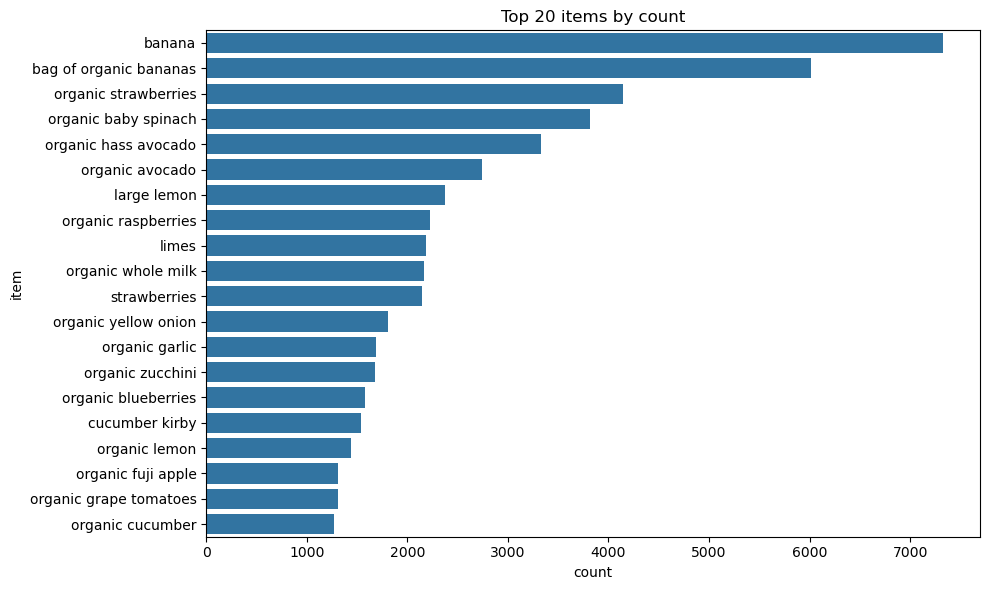

In [12]:
plt.show()

In [10]:
# Basket size distribution
basket_sizes = [len(t) for t in transactions]
pd.Series(basket_sizes).describe()

count    50000.000000
mean        10.097300
std          7.500317
min          1.000000
25%          5.000000
50%          8.000000
75%         14.000000
max        114.000000
dtype: float64

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(basket_sizes, bins=30, kde=False)
plt.title('Histogram of basket sizes (items per order)')
plt.xlabel('Items per order')
plt.tight_layout()

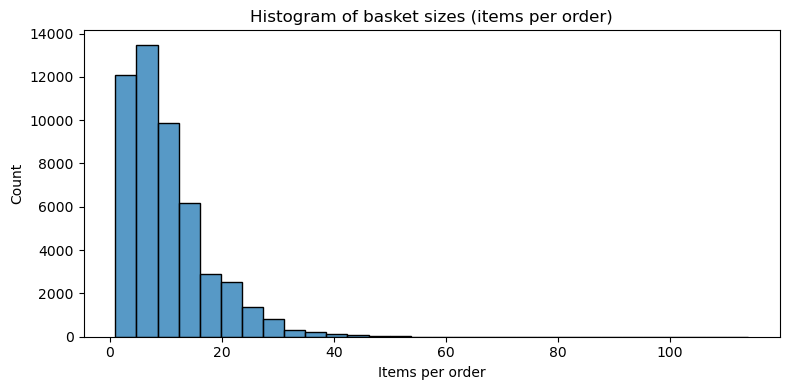

In [14]:
plt.show()

In [15]:
# One-hot encode transactions (use TransactionEncoder)
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions, sparse=False)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)
print('One-hot shape:', df_trans.shape)
df_trans.iloc[:3, :20]

One-hot shape: (50000, 29159)


,#2 coffee filters,#4 natural brown coffee filters,& go! hazelnut spread + pretzel sticks,(70% juice!) mountain raspberry juice squeeze,+energy black cherry vegetable & fruit juice,0 calorie acai raspberry water beverage,0 calorie fuji apple pear water beverage,0 calorie strawberry dragonfruit water beverage,0% fat black cherry greek yogurt y,0% fat blueberry greek yogurt,0% fat free organic milk,0% fat greek yogurt black cherry on the bottom,0% fat organic greek vanilla yogurt,0% fat peach greek yogurt,0% fat strawberry greek yogurt,0% fat superfruits greek yogurt,0% fat vanilla greek yogurt,0% greek strained yogurt,0% greek yogurt black cherry on the bottom,"0% greek, blueberry on the bottom yogurt"
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
# Function to run apriori and fpgrowth and record runtime
def run_mining(df, min_support=0.01, method='apriori'):
    start = time.perf_counter()
    if method == 'apriori':
        frequent = apriori(df, min_support=min_support, use_colnames=True)
    elif method == 'fpgrowth':
        frequent = fpgrowth(df, min_support=min_support, use_colnames=True)
    else:
        raise ValueError('Unknown method')
    elapsed = time.perf_counter() - start
    frequent['length'] = frequent['itemsets'].apply(lambda x: len(x))
    return frequent.sort_values(['length','support'], ascending=[False, False]), elapsed

# try multiple supports
supports = [0.02, 0.01, 0.005] if df_trans.shape[0] > 50 else [0.6, 0.4, 0.2]
results = {}
for s in supports:
    freq_a, t_a = run_mining(df_trans, min_support=s, method='apriori')
    freq_f, t_f = run_mining(df_trans, min_support=s, method='fpgrowth')
    results[s] = {'apriori': (freq_a, t_a), 'fpgrowth': (freq_f, t_f)}
    print(f'support={s}: Apriori itemsets={len(freq_a)} time={t_a:.3f}s | FP-Growth itemsets={len(freq_f)} time={t_f:.3f}s')

support=0.02: Apriori itemsets=40 time=9.598s | FP-Growth itemsets=40 time=406.854s
support=0.01: Apriori itemsets=121 time=39.275s | FP-Growth itemsets=121 time=402.754s
support=0.005: Apriori itemsets=339 time=209.508s | FP-Growth itemsets=339 time=437.136s


In [20]:
# Generate association rules for a chosen support level (pick first available)
chosen_support = supports[-1]
freq_apriori = results[chosen_support]['apriori'][0]
rules = association_rules(freq_apriori, metric='confidence', min_threshold=0.1)
rules = rules.sort_values('lift', ascending=False)
rules[['antecedents','consequents','support','confidence','lift']].head(15)

,antecedents,consequents,support,confidence,lift
83,(organic cilantro),(limes),0.00536,0.266402,6.101731
84,(limes),(organic cilantro),0.00536,0.122767,6.101731
52,(organic yellow onion),(organic garlic),0.00712,0.197449,5.859012
53,(organic garlic),(organic yellow onion),0.00712,0.211276,5.859012
32,(large lemon),(limes),0.00862,0.181780,4.163533
33,(limes),(large lemon),0.00862,0.197435,4.163533
46,(organic hass avocado),(organic lemon),0.00738,0.110911,3.848395
45,(organic lemon),(organic hass avocado),0.00738,0.256072,3.848395
80,(organic cucumber),(organic hass avocado),0.00558,0.220032,3.306756
88,(cucumber kirby),(organic avocado),0.00518,0.167964,3.060563


In [21]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
83,(organic cilantro),(limes),0.02012,0.04366,0.00536,0.266402,6.101731,1.0,0.004482,1.303629,0.853280,0.091749,0.232910,0.194584
84,(limes),(organic cilantro),0.04366,0.02012,0.00536,0.122767,6.101731,1.0,0.004482,1.117012,0.874283,0.091749,0.104754,0.194584
52,(organic yellow onion),(organic garlic),0.03606,0.03370,0.00712,0.197449,5.859012,1.0,0.005905,1.204035,0.860347,0.113665,0.169459,0.204362
53,(organic garlic),(organic yellow onion),0.03370,0.03606,0.00712,0.211276,5.859012,1.0,0.005905,1.222151,0.858246,0.113665,0.181771,0.204362
32,(large lemon),(limes),0.04742,0.04366,0.00862,0.181780,4.163533,1.0,0.006550,1.168805,0.797644,0.104536,0.144425,0.189607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,(organic avocado),(bag of organic bananas),0.05488,0.12024,0.00768,0.139942,1.163853,1.0,0.001081,1.022907,0.148960,0.045867,0.022394,0.101907
66,(large lemon),(bag of organic bananas),0.04742,0.12024,0.00634,0.133699,1.111933,1.0,0.000638,1.015536,0.105677,0.039301,0.015298,0.093213
22,(organic hass avocado),(banana),0.06654,0.14654,0.01080,0.162308,1.107605,1.0,0.001049,1.018824,0.104076,0.053391,0.018476,0.118004
77,(strawberries),(bag of organic bananas),0.04288,0.12024,0.00570,0.132929,1.105531,1.0,0.000544,1.014634,0.099734,0.036209,0.014423,0.090167


In [22]:
# Simple network plot for top rules (requires networkx)
try:
    import networkx as nx
    top_rules = rules.head(12).copy()
    G = nx.DiGraph()
    for _, row in top_rules.iterrows():
        a = ','.join(list(row['antecedents']))
        c = ','.join(list(row['consequents']))
        G.add_edge(a, c, weight=row['lift'])
    plt.figure(figsize=(10,6))
    pos = nx.spring_layout(G, k=1)
    nx.draw(G, pos, with_labels=True, node_size=1200, node_color='skyblue', arrowsize=20)
    labels = nx.get_edge_attributes(G,'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels={k: f"{v:.2f}" for k,v in labels.items()})
    plt.title('Top association rules (edges labelled by lift)')
    plt.axis('off')
except Exception as e:
    print('Network plot skipped (networkx not installed or error):', e)

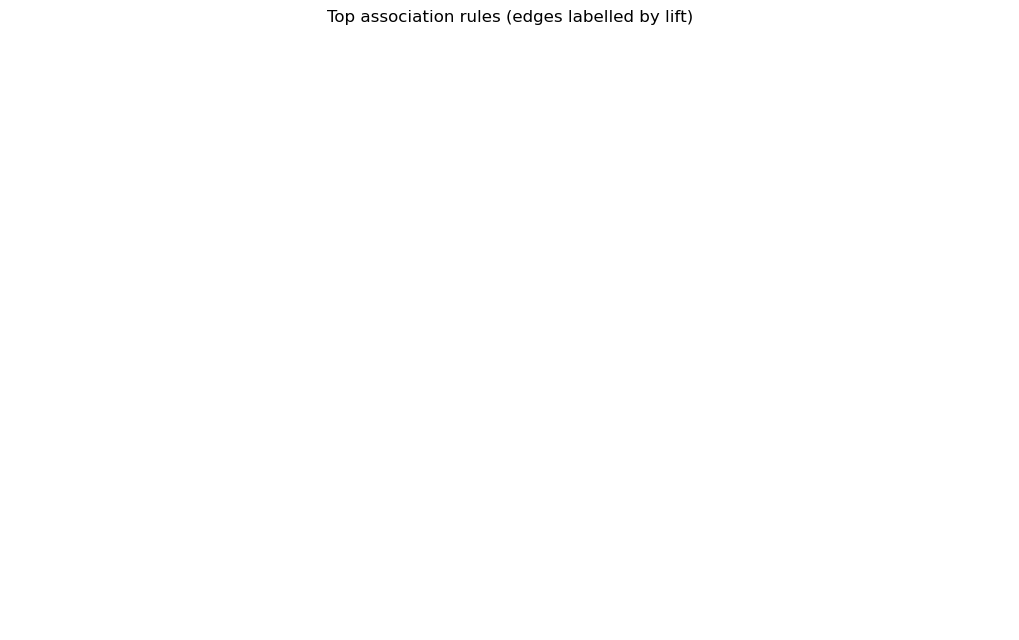

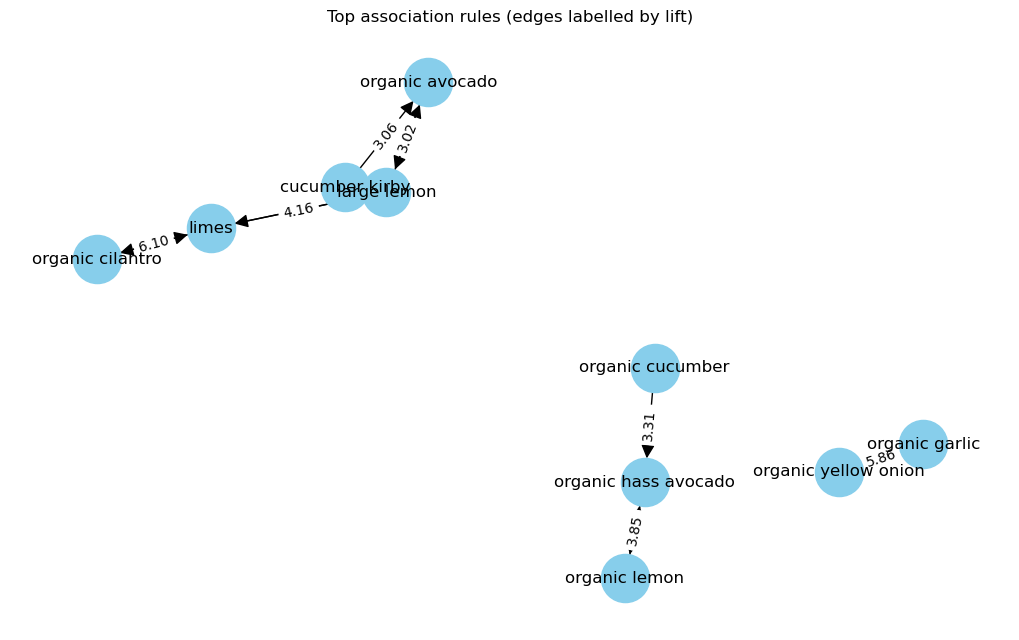

In [25]:
plt.show()

In [23]:
# Show a case where confidence is high but lift <= 1 (misleading)
if not rules.empty:
    low_lift_high_conf = rules[(rules['lift'] <= 1.0) & (rules['confidence'] > 0.6)].sort_values(['confidence','lift'], ascending=[False, True])
    if not low_lift_high_conf.empty:
        display(low_lift_high_conf[['antecedents','consequents','support','confidence','lift']].head())
    else:
        print('No high-confidence low-lift rules in this run.')
else:
    print('No rules generated to test misleadingness.')

No high-confidence low-lift rules in this run.


In [24]:
# Save frequent itemsets and rules (csv)
try:
    out_dir = './output'
    os.makedirs(out_dir, exist_ok=True)
    freq_apriori.to_csv(os.path.join(out_dir, f'frequent_itemsets_apriori_s{chosen_support}.csv'), index=False)
    rules.to_csv(os.path.join(out_dir, f'association_rules_apriori_s{chosen_support}.csv'), index=False)
    print('Saved frequent itemsets and rules to', out_dir)
except Exception as e:
    print('Save skipped:', e)

Saved frequent itemsets and rules to ./output


## Notes and next steps

"
- If you use the full Instacart dataset, consider running the mining on top-N items (e.g., top 200) to control memory.
"
- For production-scale mining on very large datasets, use distributed frameworks or stream-based mining algorithms.
"
- Optional: add segment-specific mining (by user type, time of day) to uncover conditional rules.

"
**End of notebook.**